# Sharren Elvaretta Pratamadya Fianto (244107020191)

## Langkah 1: Setup & Import

In [ ]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, pairwise_distances)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

OUTPUT_DIR = "outputKmeans_lettuce"
os.makedirs(OUTPUT_DIR, exist_ok=True)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("[INFO] Library siap.")
print(f"[INFO] Folder output: '{OUTPUT_DIR}' | Random state: {RANDOM_STATE}")

[INFO] Library siap.
[INFO] Folder output: 'outputKmeans_lettuce' | Random state: 42


## Langkah 2: Load Dataset

In [ ]:
DATASET_NAME = "lettuce_dataset_updated.csv"

if not os.path.exists(DATASET_NAME):
    try:
        from google.colab import files
        print("[INFO] Silakan upload file 'lettuce_dataset_updated.csv'")
        uploaded = files.upload()
        DATASET_NAME = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(f"File '{DATASET_NAME}' tidak ditemukan di folder kerja.")

# encoding latin-1 karena ada simbol derajat (°) pada nama kolom
df_raw = pd.read_csv(DATASET_NAME, encoding='latin-1')
df_raw.columns = [c.replace('\xb0', '°').strip() for c in df_raw.columns]
print(f"[DATA] Dimensi dataset: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")
print(f"[DATA] Kolom: {list(df_raw.columns)}")
print(f"[DATA] Missing value total: {int(df_raw.isna().sum().sum())}")
df_raw.head()

[INFO] Silakan upload file 'lettuce_dataset_updated.csv'


Saving lettuce_dataset_updated.csv to lettuce_dataset_updated.csv
[DATA] Dimensi dataset: 3169 baris x 9 kolom
[DATA] Kolom: ['Plant_ID', 'Date', 'Temperature (°C)', 'Humidity (%)', 'TDS Value (ppm)', 'pH Level', 'Growth Days', 'Temperature (F)', 'Humidity']
[DATA] Missing value total: 0


,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity
0,1,8/3/2023,33.4,53,582,6.4,1,92.12,0.53
1,1,8/4/2023,33.5,53,451,6.1,2,92.30,0.53
2,1,8/5/2023,33.4,59,678,6.4,3,92.12,0.59
3,1,8/6/2023,33.4,68,420,6.4,4,92.12,0.68
4,1,8/7/2023,33.4,74,637,6.5,5,92.12,0.74


## Langkah 3: Preprocessing + Fungsi Pembagian Data

In [ ]:
# Kolom dibuang:
#  - Plant_ID, Date              -> identitas/metadata, bukan fitur
#  - Temperature (F), Humidity   -> duplikat (redundan) dari Temperature (°C) dan Humidity (%)
FEATURE_COLS = ['Temperature (°C)', 'Humidity (%)', 'TDS Value (ppm)', 'pH Level', 'Growth Days']
missing = [c for c in FEATURE_COLS if c not in df_raw.columns]
assert not missing, f"Kolom tidak ditemukan: {missing}. Cek nama kolom di CELL 2."

def preprocess(df_subset):
    """Imputasi median -> StandardScaler -> L2 Normalization (unit hypersphere)."""
    feats = df_subset[FEATURE_COLS].astype(float).copy()
    feats[:] = SimpleImputer(strategy='median').fit_transform(feats)
    X_std = StandardScaler().fit_transform(feats.values)
    X_norm = Normalizer(norm='l2').fit_transform(X_std)
    return feats, X_norm

# Skenario pembagian data (sampling acak, reproducible)
SPLITS = {
    "Full Data (100%)": 1.0,
    "80% Data": 0.8,
    "50% Data": 0.5,
    "30% Data": 0.3,
}

datasets = {}
for name, frac in SPLITS.items():
    sub = df_raw.copy() if frac == 1.0 else df_raw.sample(frac=frac, random_state=RANDOM_STATE)
    sub = sub.sort_index()
    feats, X_norm = preprocess(sub)
    datasets[name] = {"df_raw": sub, "features": feats, "X": X_norm}
    print(f"[SPLIT] {name:<18} -> {X_norm.shape[0]:>5} sampel x {X_norm.shape[1]} fitur")

[SPLIT] Full Data (100%)   ->  3169 sampel x 5 fitur
[SPLIT] 80% Data           ->  2535 sampel x 5 fitur
[SPLIT] 50% Data           ->  1584 sampel x 5 fitur
[SPLIT] 30% Data           ->   951 sampel x 5 fitur


## Langkah 4: Kelas Spherical K Means (Cosine Distance)

In [ ]:
class KMeansCosine:
    """Spherical K-Means: assignment pakai Cosine Distance, centroid = rata-rata ter-normalisasi."""
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = 0.0
        self.n_iter_ = 0
        self.execution_time_ = 0.0

    def _dist(self, X, C):
        return pairwise_distances(X, C, metric='cosine')

    def _init_centroids(self, X):
        rng = np.random.RandomState(self.random_state)
        n = X.shape[0]
        centroids = [X[rng.randint(n)]]
        for _ in range(1, self.n_clusters):
            d = np.min(self._dist(X, np.array(centroids)), axis=1) ** 2
            s = d.sum()
            p = np.ones(n) / n if s == 0 else d / s
            centroids.append(X[rng.choice(n, p=p)])
        C = np.array(centroids)
        nr = np.linalg.norm(C, axis=1, keepdims=True)
        nr[nr == 0] = 1e-10
        return C / nr

    def fit(self, X):
        t0 = time.perf_counter()
        nr = np.linalg.norm(X, axis=1, keepdims=True)
        nr[nr == 0] = 1e-10
        Xc = X / nr
        self.centroids = self._init_centroids(Xc)
        rng = np.random.RandomState(self.random_state)

        for it in range(self.max_iter):
            self.n_iter_ = it + 1
            labels = np.argmin(self._dist(Xc, self.centroids), axis=1)
            new_c = np.zeros_like(self.centroids)
            for k in range(self.n_clusters):
                pts = Xc[labels == k]
                if len(pts) == 0:
                    new_c[k] = Xc[rng.randint(len(Xc))]
                else:
                    m = pts.mean(axis=0)
                    n_ = np.linalg.norm(m)
                    new_c[k] = m / (n_ if n_ > 0 else 1.0)
            shift = np.linalg.norm(new_c - self.centroids)
            self.centroids = new_c
            self.labels_ = labels
            if shift <= self.tol:
                break

        d = self._dist(Xc, self.centroids)
        self.inertia_ = float(np.sum(d[np.arange(len(Xc)), self.labels_]))
        self.execution_time_ = float(time.perf_counter() - t0)
        return self

def find_elbow_point(k_vals, inertias):
    """Titik dengan jarak terjauh dari garis lurus (k_awal -> k_akhir)."""
    p1 = np.array([k_vals[0], inertias[0]], dtype=float)
    p2 = np.array([k_vals[-1], inertias[-1]], dtype=float)
    u = (p2 - p1) / np.linalg.norm(p2 - p1)
    dists = []
    for k, s in zip(k_vals, inertias):
        v = np.array([k, s], dtype=float) - p1
        dists.append(np.linalg.norm(v - np.dot(v, u) * u))
    return k_vals[int(np.argmax(dists))]

print("[INFO] Kelas KMeansCosine & fungsi elbow siap.")

[INFO] Kelas KMeansCosine & fungsi elbow siap.


## Langkah 5: Elbow Method

[ELBOW] Full Data (100%)   -> k optimal = 4 (inertia = 1251.48)


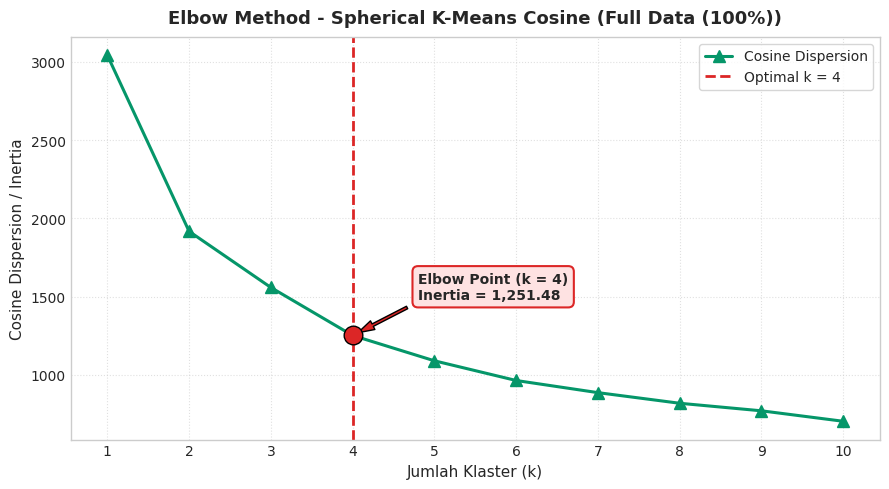

[ELBOW] 80% Data           -> k optimal = 3 (inertia = 1184.78)


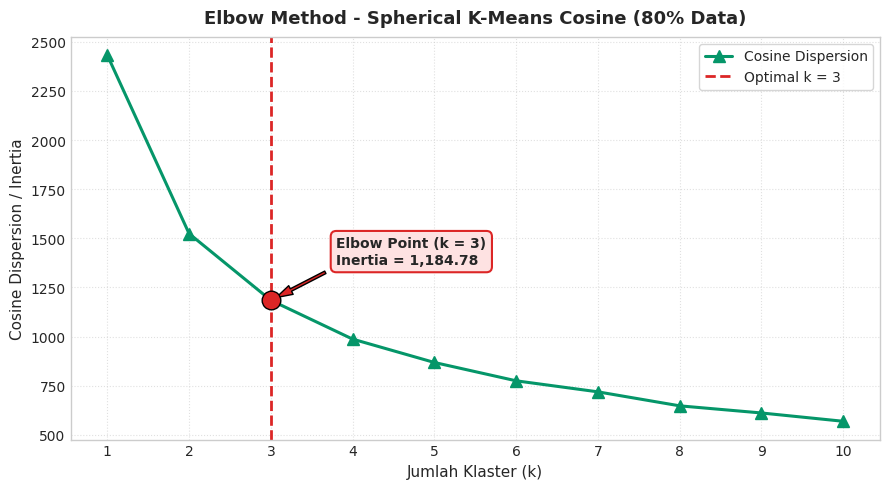

[ELBOW] 50% Data           -> k optimal = 3 (inertia = 727.19)


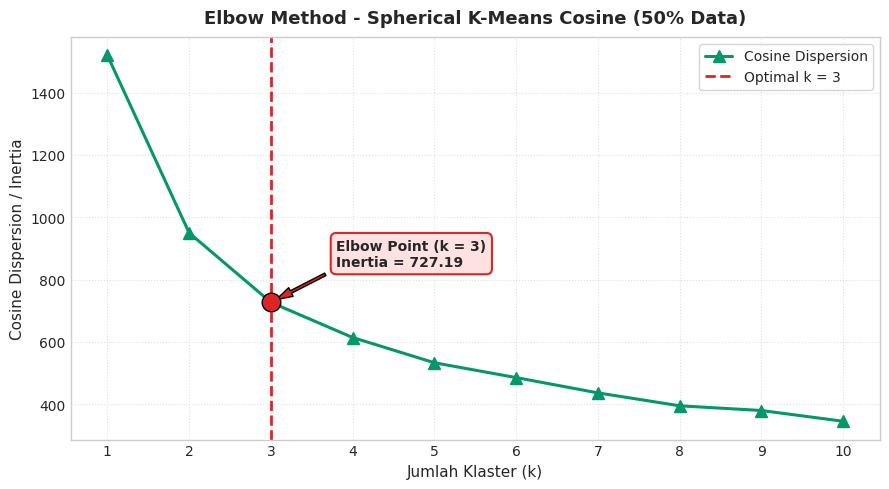

[ELBOW] 30% Data           -> k optimal = 3 (inertia = 434.39)


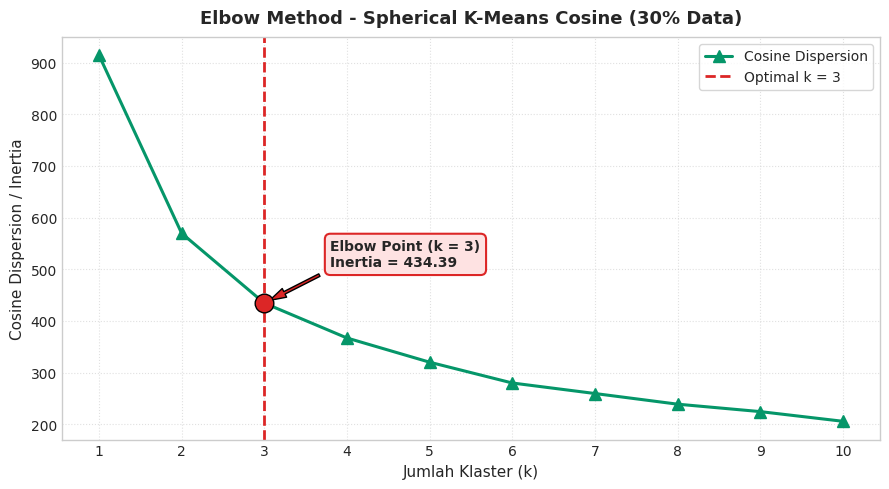

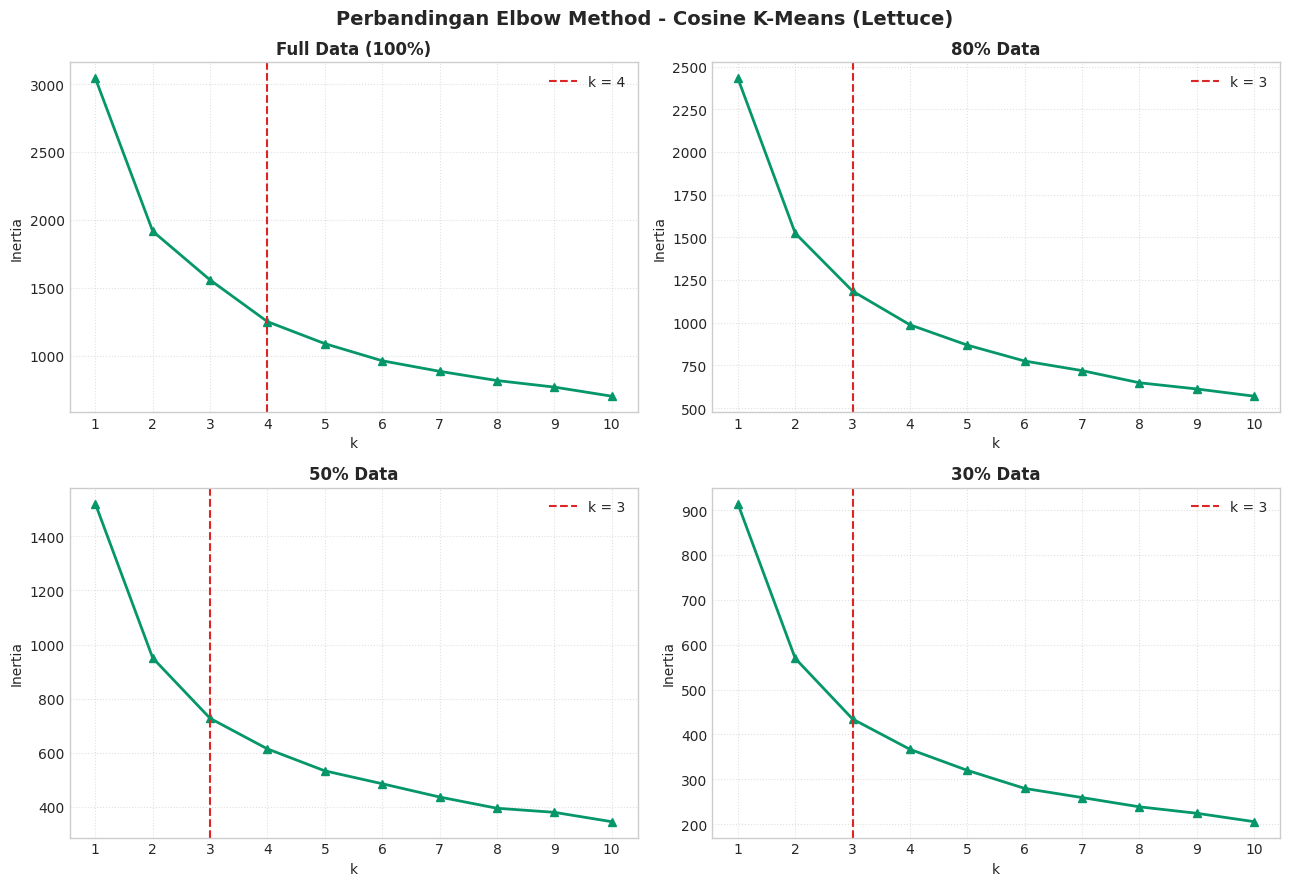

In [ ]:
k_range = list(range(1, 11))
elbow_results = {}

for name, d in datasets.items():
    inertias = []
    for k in k_range:
        km = KMeansCosine(n_clusters=k, max_iter=200, random_state=RANDOM_STATE).fit(d["X"])
        inertias.append(km.inertia_)
    opt_k = find_elbow_point(k_range, inertias)
    elbow_results[name] = {"inertias": inertias, "optimal_k": opt_k}
    print(f"[ELBOW] {name:<18} -> k optimal = {opt_k} (inertia = {inertias[opt_k-1]:.2f})")

    plt.figure(figsize=(9, 5))
    plt.plot(k_range, inertias, marker='^', markersize=8, linewidth=2.2, color='#059669', label='Cosine Dispersion')
    plt.axvline(x=opt_k, color='#DC2626', linestyle='--', linewidth=2, label=f'Optimal k = {opt_k}')
    plt.scatter([opt_k], [inertias[opt_k-1]], color='#DC2626', s=180, zorder=5, edgecolor='black')
    plt.title(f'Elbow Method - Spherical K-Means Cosine ({name})', fontsize=13, fontweight='bold', pad=10)
    plt.xlabel('Jumlah Klaster (k)', fontsize=11)
    plt.ylabel('Cosine Dispersion / Inertia', fontsize=11)
    plt.xticks(k_range)
    plt.annotate(f'Elbow Point (k = {opt_k})\nInertia = {inertias[opt_k-1]:,.2f}',
                 xy=(opt_k, inertias[opt_k-1]),
                 xytext=(min(opt_k + 0.8, 8), inertias[opt_k-1] + (max(inertias) - min(inertias)) * 0.1),
                 arrowprops=dict(facecolor='#DC2626', shrink=0.08, width=2, headwidth=7),
                 bbox=dict(boxstyle="round,pad=0.4", facecolor="#FEE2E2", edgecolor="#DC2626", lw=1.5),
                 fontweight='bold', fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(frameon=True, facecolor='white')
    plt.tight_layout()
    fname = f"elbow_{int(SPLITS[name]*100)}pct.png"
    plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=200)
    plt.show()

# Gabungan 4 elbow dalam 1 gambar
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (name, r) in zip(axes.ravel(), elbow_results.items()):
    ax.plot(k_range, r["inertias"], marker='^', color='#059669', linewidth=2)
    ax.axvline(r["optimal_k"], color='#DC2626', linestyle='--', label=f'k = {r["optimal_k"]}')
    ax.set_title(name, fontweight='bold'); ax.set_xlabel('k'); ax.set_ylabel('Inertia')
    ax.set_xticks(k_range); ax.legend(); ax.grid(True, linestyle=':', alpha=0.6)
plt.suptitle('Perbandingan Elbow Method - Cosine K-Means (Lettuce)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "elbow_all_splits.png"), dpi=200)
plt.show()

## Langkah 6: Clustering Final + Metrik Evaluasi

In [ ]:
models, rows = {}, []
for name, d in datasets.items():
    k = elbow_results[name]["optimal_k"]
    k = max(k, 2)  # silhouette/DB/CH butuh minimal 2 klaster
    model = KMeansCosine(n_clusters=k, max_iter=300, tol=1e-4, random_state=RANDOM_STATE).fit(d["X"])
    models[name] = model
    rows.append({
        'Skenario Data': name,
        'Jumlah Sampel': d["X"].shape[0],
        'Optimal k': k,
        'Silhouette Score (↑)': round(float(silhouette_score(d["X"], model.labels_, metric='cosine')), 4),
        'Davies-Bouldin Index (↓)': round(float(davies_bouldin_score(d["X"], model.labels_)), 4),
        'Calinski-Harabasz Index (↑)': round(float(calinski_harabasz_score(d["X"], model.labels_)), 2),
        'Execution Time (s) (↓)': round(model.execution_time_, 5),
        'Iterations (↓)': model.n_iter_,
        'Objective Value (Inertia) (↓)': round(model.inertia_, 2),
    })

eval_df = pd.DataFrame(rows)
print("=" * 100)
print("TABEL EVALUASI K-MEANS COSINE - DATASET LETTUCE")
print("=" * 100)
print(eval_df.to_string(index=False))
print("=" * 100)

# Simpan Excel: ringkasan + data terklaster tiap skenario
excel_path = os.path.join(OUTPUT_DIR, "evaluasi_kmeans_cosine_lettuce.xlsx")
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)
    for name, d in datasets.items():
        out = d["df_raw"].copy()
        out['Cluster_Cosine'] = models[name].labels_
        sheet = name.replace('%', 'pct').replace('(', '').replace(')', '').replace(' ', '_')[:31]
        out.to_excel(writer, sheet_name=sheet, index=False)
print(f"[SIMPAN] Excel: '{excel_path}'")
eval_df

TABEL EVALUASI K-MEANS COSINE - DATASET LETTUCE
   Skenario Data  Jumlah Sampel  Optimal k  Silhouette Score (↑)  Davies-Bouldin Index (↓)  Calinski-Harabasz Index (↑)  Execution Time (s) (↓)  Iterations (↓)  Objective Value (Inertia) (↓)
Full Data (100%)           3169          4                0.2926                    1.6785                       607.33                 0.03534              24                        1251.48
        80% Data           2535          3                0.3093                    1.9689                       501.83                 0.05020              47                        1184.78
        50% Data           1584          3                0.3153                    1.8910                       326.79                 0.01673              11                         727.19
        30% Data            951          3                0.3195                    1.8909                       198.78                 0.02050              16                         434.

,Skenario Data,Jumlah Sampel,Optimal k,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑),Execution Time (s) (↓),Iterations (↓),Objective Value (Inertia) (↓)
0,Full Data (100%),3169,4,0.2926,1.6785,607.33,0.03534,24,1251.48
1,80% Data,2535,3,0.3093,1.9689,501.83,0.05020,47,1184.78
2,50% Data,1584,3,0.3153,1.8910,326.79,0.01673,11,727.19
3,30% Data,951,3,0.3195,1.8909,198.78,0.02050,16,434.39


## Langkah 7: Visualisasi Pca 2D Pemetaan Klaster

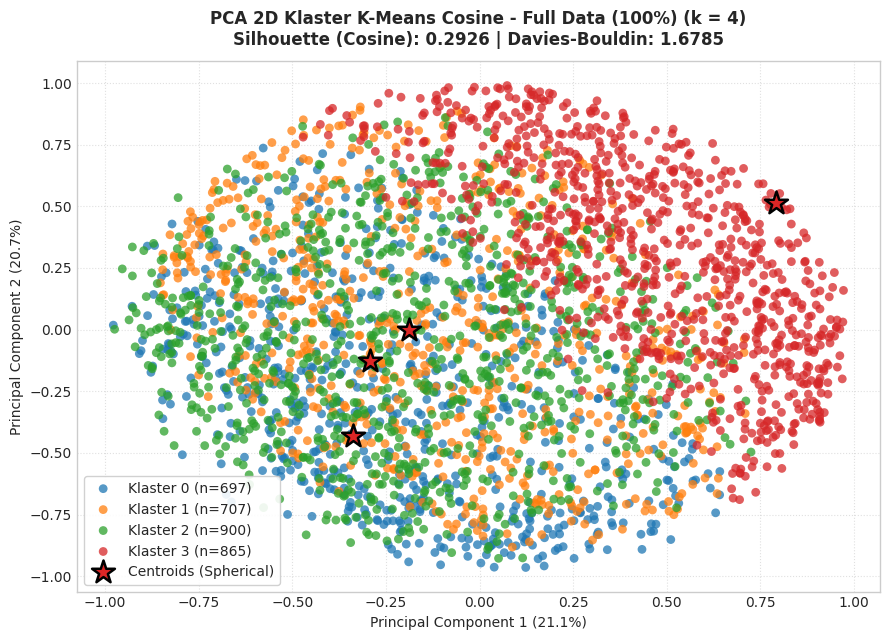

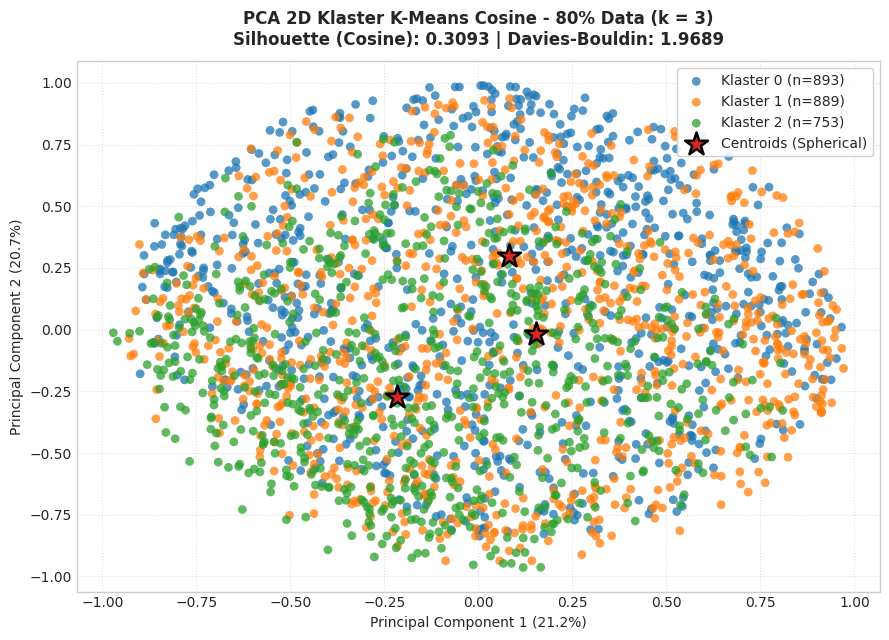

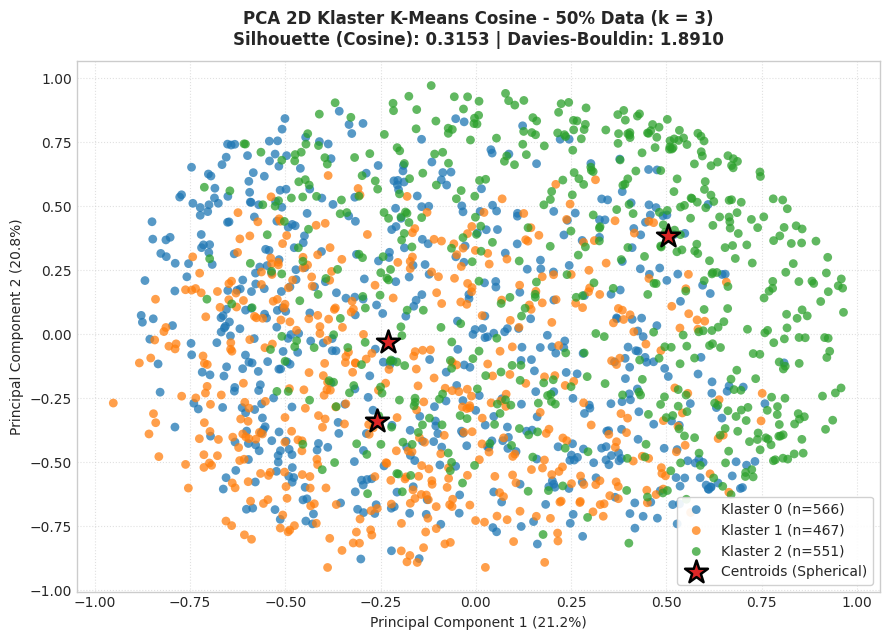

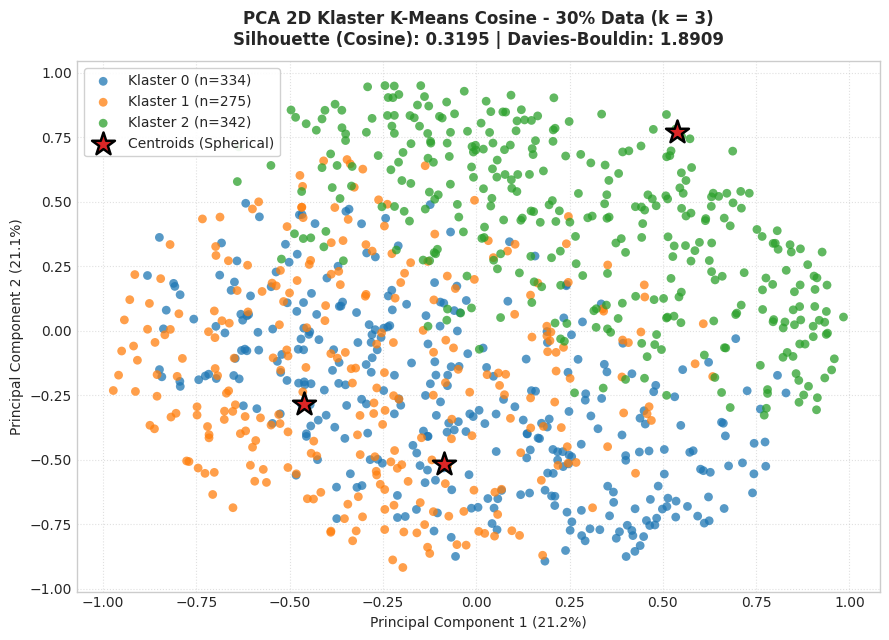

In [ ]:
for name, d in datasets.items():
    model = models[name]
    k = model.n_clusters
    row = eval_df[eval_df['Skenario Data'] == name].iloc[0]
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(d["X"])
    C_pca = pca.transform(model.centroids)

    plt.figure(figsize=(9, 6.5))
    palette = sns.color_palette("tab10", k)
    for c in range(k):
        m = model.labels_ == c
        plt.scatter(X_pca[m, 0], X_pca[m, 1], color=palette[c], label=f'Klaster {c} (n={m.sum()})',
                    alpha=0.75, s=40, edgecolors='none')
    plt.scatter(C_pca[:, 0], C_pca[:, 1], marker='*', s=300, c='#DC2626', edgecolor='black',
                linewidth=1.8, label='Centroids (Spherical)', zorder=10)
    plt.title(f'PCA 2D Klaster K-Means Cosine - {name} (k = {k})\n'
              f'Silhouette (Cosine): {row["Silhouette Score (↑)"]:.4f} | Davies-Bouldin: {row["Davies-Bouldin Index (↓)"]:.4f}',
              fontsize=12, fontweight='bold', pad=12)
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"cluster_{int(SPLITS[name]*100)}pct.png"), dpi=200)
    plt.show()

## Langkah 8: Grafik Bar Perbandingan Metrik

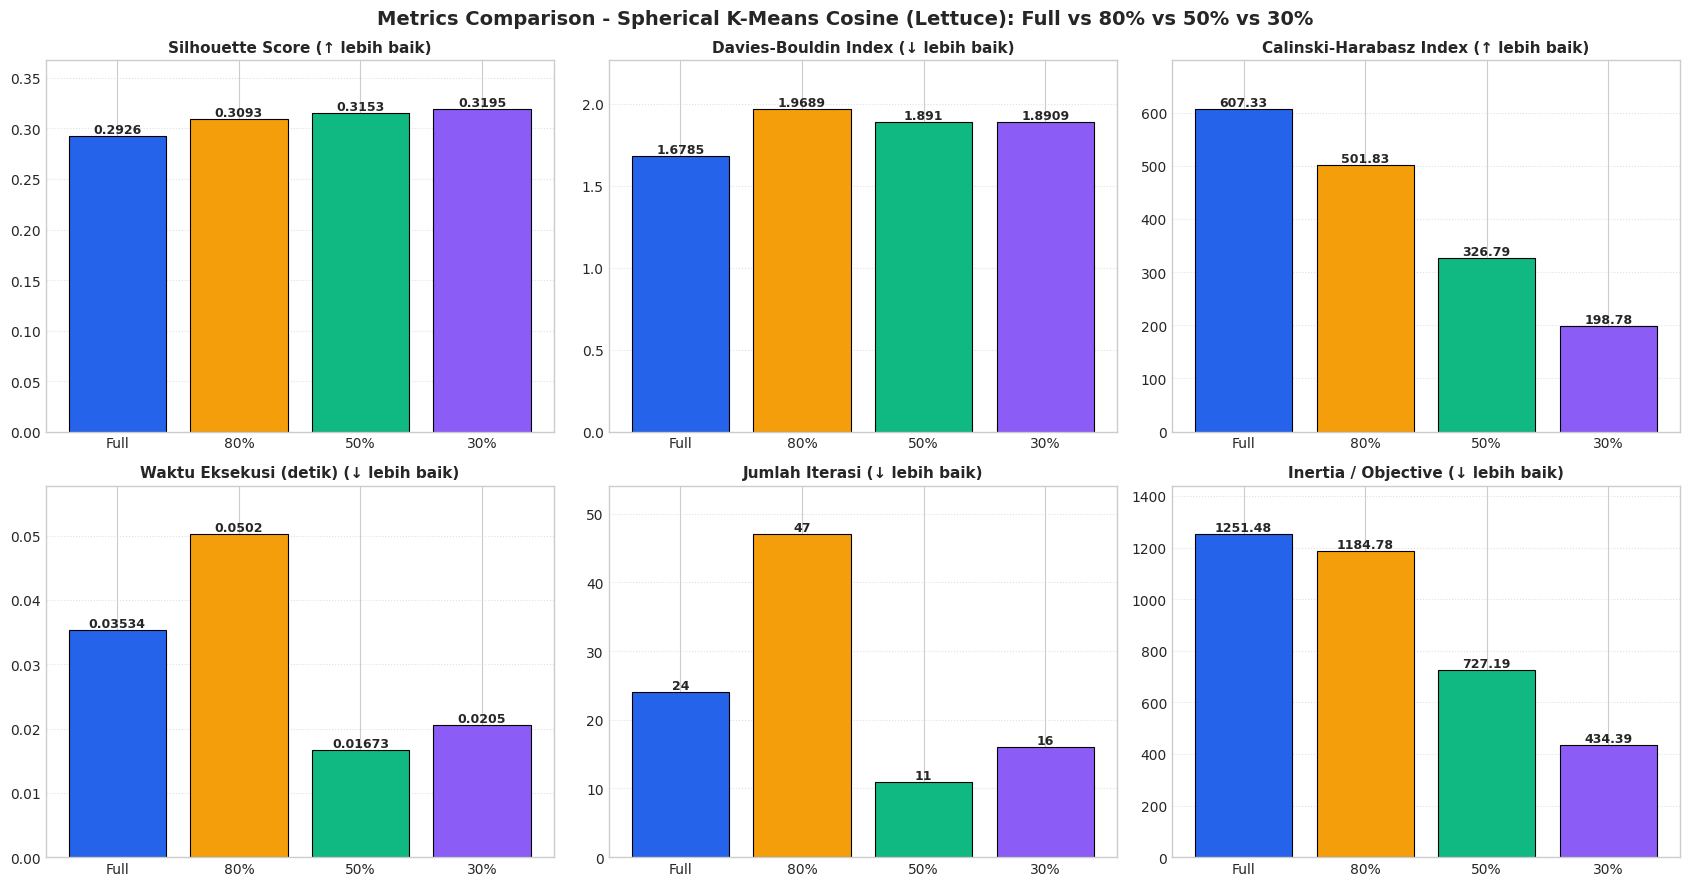

[SIMPAN] 'outputKmeans_lettuce/metrics_comparison_bar.png'


In [ ]:
metric_cols = [
    ('Silhouette Score (↑)', 'Silhouette Score (↑ lebih baik)'),
    ('Davies-Bouldin Index (↓)', 'Davies-Bouldin Index (↓ lebih baik)'),
    ('Calinski-Harabasz Index (↑)', 'Calinski-Harabasz Index (↑ lebih baik)'),
    ('Execution Time (s) (↓)', 'Waktu Eksekusi (detik) (↓ lebih baik)'),
    ('Iterations (↓)', 'Jumlah Iterasi (↓ lebih baik)'),
    ('Objective Value (Inertia) (↓)', 'Inertia / Objective (↓ lebih baik)'),
]
colors = ['#2563EB', '#F59E0B', '#10B981', '#8B5CF6']
labels = eval_df['Skenario Data'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, (col, title) in zip(axes.ravel(), metric_cols):
    vals = eval_df[col].values
    bars = ax.bar(range(len(labels)), vals, color=colors[:len(labels)], edgecolor='black', linewidth=0.8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels([l.replace(' Data', '').replace(' (100%)', '') for l in labels], fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, axis='y', linestyle=':', alpha=0.6)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height(), f'{v:g}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.15 if max(vals) > 0 else 1)
plt.suptitle('Metrics Comparison - Spherical K-Means Cosine (Lettuce): Full vs 80% vs 50% vs 30%',
             fontsize=14, fontweight='bold')
plt.tight_layout()
bar_path = os.path.join(OUTPUT_DIR, "metrics_comparison_bar.png")
plt.savefig(bar_path, dpi=200)
plt.show()
print(f"[SIMPAN] '{bar_path}'")